## Problem Statement
#### The goal of this project is to build a data-driven model that can:
#### - Predict the popularity of a song based on its audio features and platform presence
#### - Provide actionable insights to company teams on what attributes are most relevant for streaming performance


In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_validate

## Import Data from Kaggle

In [90]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nelgiriyewithana/top-spotify-songs-2023")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Derum\.cache\kagglehub\datasets\nelgiriyewithana\top-spotify-songs-2023\versions\1


In [91]:
files = os.listdir(path)

print("Files:", files)

Files: ['spotify-2023.csv']


In [92]:
df= pd.read_csv(os.path.join(path, "spotify-2023.csv"), encoding='latin1')

In [93]:
df.head(10)

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6
5,Sprinter,"Dave, Central Cee",2,2023,6,1,2186,91,183706234,67,...,141,C#,Major,92,66,58,19,0,8,24
6,Ella Baila Sola,"Eslabon Armado, Peso Pluma",2,2023,3,16,3090,50,725980112,34,...,148,F,Minor,67,83,76,48,0,8,3
7,Columbia,Quevedo,1,2023,7,7,714,43,58149378,25,...,100,F,Major,67,26,71,37,0,11,4
8,fukumean,Gunna,1,2023,5,15,1096,83,95217315,60,...,130,C#,Minor,85,22,62,12,0,28,9
9,La Bebe - Remix,"Peso Pluma, Yng Lvcas",2,2023,3,17,2953,44,553634067,49,...,170,D,Minor,81,56,48,21,0,8,33


## Clean Data

In [94]:
df.dtypes

track_name              object
artist(s)_name          object
artist_count             int64
released_year            int64
released_month           int64
released_day             int64
in_spotify_playlists     int64
in_spotify_charts        int64
streams                 object
in_apple_playlists       int64
in_apple_charts          int64
in_deezer_playlists     object
in_deezer_charts         int64
in_shazam_charts        object
bpm                      int64
key                     object
mode                    object
danceability_%           int64
valence_%                int64
energy_%                 int64
acousticness_%           int64
instrumentalness_%       int64
liveness_%               int64
speechiness_%            int64
dtype: object

In [95]:
df.count()

track_name              953
artist(s)_name          953
artist_count            953
released_year           953
released_month          953
released_day            953
in_spotify_playlists    953
in_spotify_charts       953
streams                 953
in_apple_playlists      953
in_apple_charts         953
in_deezer_playlists     953
in_deezer_charts        953
in_shazam_charts        903
bpm                     953
key                     858
mode                    953
danceability_%          953
valence_%               953
energy_%                953
acousticness_%          953
instrumentalness_%      953
liveness_%              953
speechiness_%           953
dtype: int64

In [96]:
df.isnull().sum()

track_name               0
artist(s)_name           0
artist_count             0
released_year            0
released_month           0
released_day             0
in_spotify_playlists     0
in_spotify_charts        0
streams                  0
in_apple_playlists       0
in_apple_charts          0
in_deezer_playlists      0
in_deezer_charts         0
in_shazam_charts        50
bpm                      0
key                     95
mode                     0
danceability_%           0
valence_%                0
energy_%                 0
acousticness_%           0
instrumentalness_%       0
liveness_%               0
speechiness_%            0
dtype: int64

In [97]:
df['in_shazam_charts'].unique()

array(['826', '382', '949', '548', '425', '946', '418', '194', '953',
       '339', '251', '168', '1,021', '1,281', nan, '187', '0', '1,173',
       '29', '150', '73', '139', '1,093', '96', '211', '325', '294',
       '197', '27', '310', '354', '184', '212', '81', '82', '100', '62',
       '69', '727', '311', '1,133', '102', '332', '259', '140', '16',
       '110', '810', '176', '615', '210', '216', '215', '167', '37',
       '171', '272', '529', '26', '5', '169', '230', '84', '154', '93',
       '115', '72', '8', '323', '49', '1,451', '1,170', '429', '162',
       '10', '478', '236', '200', '78', '266', '486', '204', '34', '202',
       '312', '32', '153', '519', '458', '48', '666', '14', '925', '88',
       '203', '44', '74', '638', '64', '71', '2', '3', '136', '148', '22',
       '368', '1', '189', '52', '9', '31', '66', '208', '28', '558',
       '195', '13', '60', '503', '56', '15', '454', '40', '285', '129',
       '58', '117', '47', '20', '30', '80', '263', '116', '57', '39',
  

In [98]:
df['key'].unique()

array(['B', 'C#', 'F', 'A', 'D', 'F#', nan, 'G#', 'G', 'E', 'A#', 'D#'],
      dtype=object)

#### Based on the previous outputs, the following data cleaning steps are necessary for the feature 'in_shazam_charts':
#### - Convert all values to integers
#### - Remove commas
#### - Replace nan with 0

In [99]:
df['in_shazam_charts'] = (
    df['in_shazam_charts']
    .str.replace(',','')
    .fillna(0)
    .astype(int)
)

df['in_shazam_charts'].dtype

dtype('int64')

#### Following data cleaning steps for the features 'key' and 'mode':
#### - Fill missing key values with 'C', since the missing entries belong to songs in the key of C (major or minor)
#### - Convert mode from text to binary (0 for minor and 1 for major)

In [100]:
df['key'] = df['key'].fillna('C')
df[df['key'] == 'C'][['track_name','mode']]

,track_name,mode
12,Flowers,Major
17,What Was I Made For? [From The Motion Picture ...,Major
22,I Wanna Be Yours,Minor
35,Los del Espacio,Major
44,Barbie World (with Aqua) [From Barbie The Album],Major
...,...,...
899,Hold Me Closer,Major
901,After LIKE,Major
903,B.O.T.A. (Baddest Of Them All) - Edit,Major
938,Labyrinth,Major


In [101]:
df['mode'] = df['mode'].map({'Minor': 0, 'Major': 1})
df['mode']

0      1
1      1
2      1
3      1
4      0
      ..
948    1
949    1
950    1
951    1
952    0
Name: mode, Length: 953, dtype: int64

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts      953 non-null    int64 
 14  bpm                   953 non-null    int64 
 15  key                   953 non-null    ob

#### From the above output the next step is to convert columns with the data type object to numerical formats (integers or floats)

In [103]:
df.select_dtypes(include='object').columns

Index(['track_name', 'artist(s)_name', 'streams', 'in_deezer_playlists',
       'key'],
      dtype='object')

In [104]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col} ({df[col].nunique()} unique values):\n{df[col].unique()}")


track_name (943 unique values):
['Seven (feat. Latto) (Explicit Ver.)' 'LALA' 'vampire' 'Cruel Summer'
 'WHERE SHE GOES' 'Sprinter' 'Ella Baila Sola' 'Columbia' 'fukumean'
 'La Bebe - Remix' 'un x100to' 'Super Shy' 'Flowers' 'Daylight'
 'As It Was' 'Kill Bill' 'Cupid - Twin Ver.'
 'What Was I Made For? [From The Motion Picture "Barbie"]' 'Classy 101'
 'Like Crazy' 'LADY GAGA'
 'I Can See You (Taylorï¿½ï¿½ï¿½s Version) (From The ' 'I Wanna Be Yours'
 'Peso Pluma: Bzrp Music Sessions, Vol. 55'
 'Popular (with Playboi Carti & Madonna) - The Idol Vol. 1 (Music from the HBO Original Series)'
 'SABOR FRESA' 'Calm Down (with Selena Gomez)' 'MOJABI GHOST' 'Last Night'
 'Dance The Night (From Barbie The Album)' 'Rush' 'TULUM' "Creepin'"
 'Anti-Hero' 'TQG' 'Los del Espacio' 'Frï¿½ï¿½gil (feat. Grupo Front'
 'Blank Space' 'Style' 'TQM' 'El Azul'
 'Sunflower - Spider-Man: Into the Spider-Verse' "I'm Good (Blue)"
 'See You Again' 'Barbie World (with Aqua) [From Barbie The Album]'
 'Angels Like You

#### Looking at the output there is a weird entry in the 'streams' column. Since it is only one row it will be deleted

In [105]:
df[df['streams'].astype(str).str.contains('BPM')]

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
574,Love Grows (Where My Rosemary Goes),Edison Lighthouse,1,1970,1,1,2877,0,BPM110KeyAModeMajorDanceability53Valence75Ener...,16,...,110,A,1,53,75,69,7,0,17,3


In [106]:
df = df.drop(574)

#### Now the object types can be converted to numeric types

In [107]:
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')
df['streams'].dtype

dtype('int64')

In [108]:
df['in_deezer_playlists'] = (
    df['in_deezer_playlists']
    .str.replace(',','')
    .fillna(0)
    .astype(int)
)

df['in_deezer_playlists'].dtype

dtype('int64')

#### The object type columns 'Track_name' and 'Artist_name' will be dropped, since the many unique values are hard to use in a model

In [109]:
df.drop(['track_name', 'artist(s)_name'], axis=1, inplace=True)

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 952 entries, 0 to 952
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   artist_count          952 non-null    int64 
 1   released_year         952 non-null    int64 
 2   released_month        952 non-null    int64 
 3   released_day          952 non-null    int64 
 4   in_spotify_playlists  952 non-null    int64 
 5   in_spotify_charts     952 non-null    int64 
 6   streams               952 non-null    int64 
 7   in_apple_playlists    952 non-null    int64 
 8   in_apple_charts       952 non-null    int64 
 9   in_deezer_playlists   952 non-null    int64 
 10  in_deezer_charts      952 non-null    int64 
 11  in_shazam_charts      952 non-null    int64 
 12  bpm                   952 non-null    int64 
 13  key                   952 non-null    object
 14  mode                  952 non-null    int64 
 15  danceability_%        952 non-null    int64 


#### The remaining object type column 'key' will be encoded since it has a limited number of unique values but could still be important during model training

In [111]:
le = LabelEncoder()
df['key_encoded'] = le.fit_transform(df['key'])

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 952 entries, 0 to 952
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   artist_count          952 non-null    int64 
 1   released_year         952 non-null    int64 
 2   released_month        952 non-null    int64 
 3   released_day          952 non-null    int64 
 4   in_spotify_playlists  952 non-null    int64 
 5   in_spotify_charts     952 non-null    int64 
 6   streams               952 non-null    int64 
 7   in_apple_playlists    952 non-null    int64 
 8   in_apple_charts       952 non-null    int64 
 9   in_deezer_playlists   952 non-null    int64 
 10  in_deezer_charts      952 non-null    int64 
 11  in_shazam_charts      952 non-null    int64 
 12  bpm                   952 non-null    int64 
 13  key                   952 non-null    object
 14  mode                  952 non-null    int64 
 15  danceability_%        952 non-null    int64 


## Exploratory Data Analysis (EDA)


#### Questions for the EDA:
#### - What is the overall distribution of the target variable (streams)?
#### - Are some musical/audio features highly related to popularity?
#### - Do certain keys, modes, bpm or months lead to more popular songs?
#### - Do platform variables actually influence popularity?

#### What is the overall distribution of the target variable (streams)?

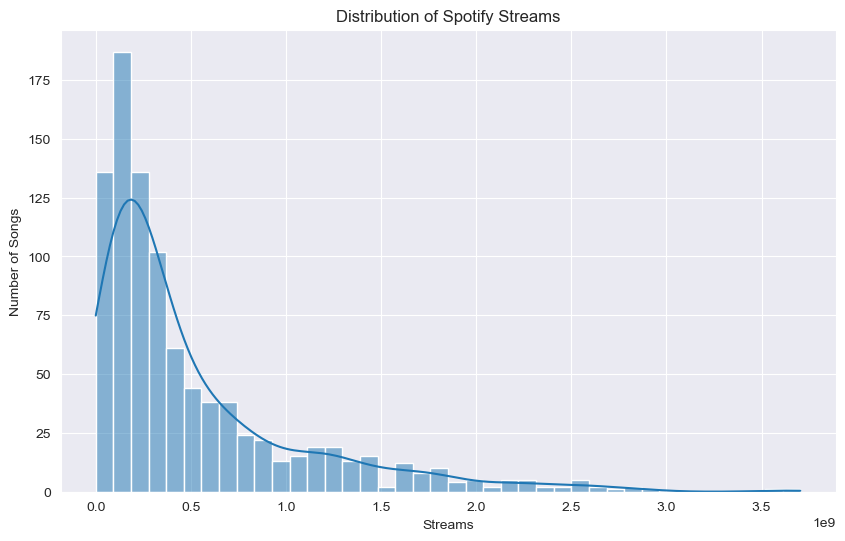

In [113]:
plt.figure(figsize = (10,6))
sns.histplot(df['streams'], kde=True, bins=40)
plt.title("Distribution of Spotify Streams")
plt.xlabel("Streams")
plt.ylabel("Number of Songs")
plt.grid(True)
plt.show()

Explanation:
The streams variable is right-skewed, there a few songs with very high streams, while most have lower values. This can be an indicator that stream counts vary a lot and it is better to log-transform this variable for modeling.

#### Are some musical features highly related to popularity?

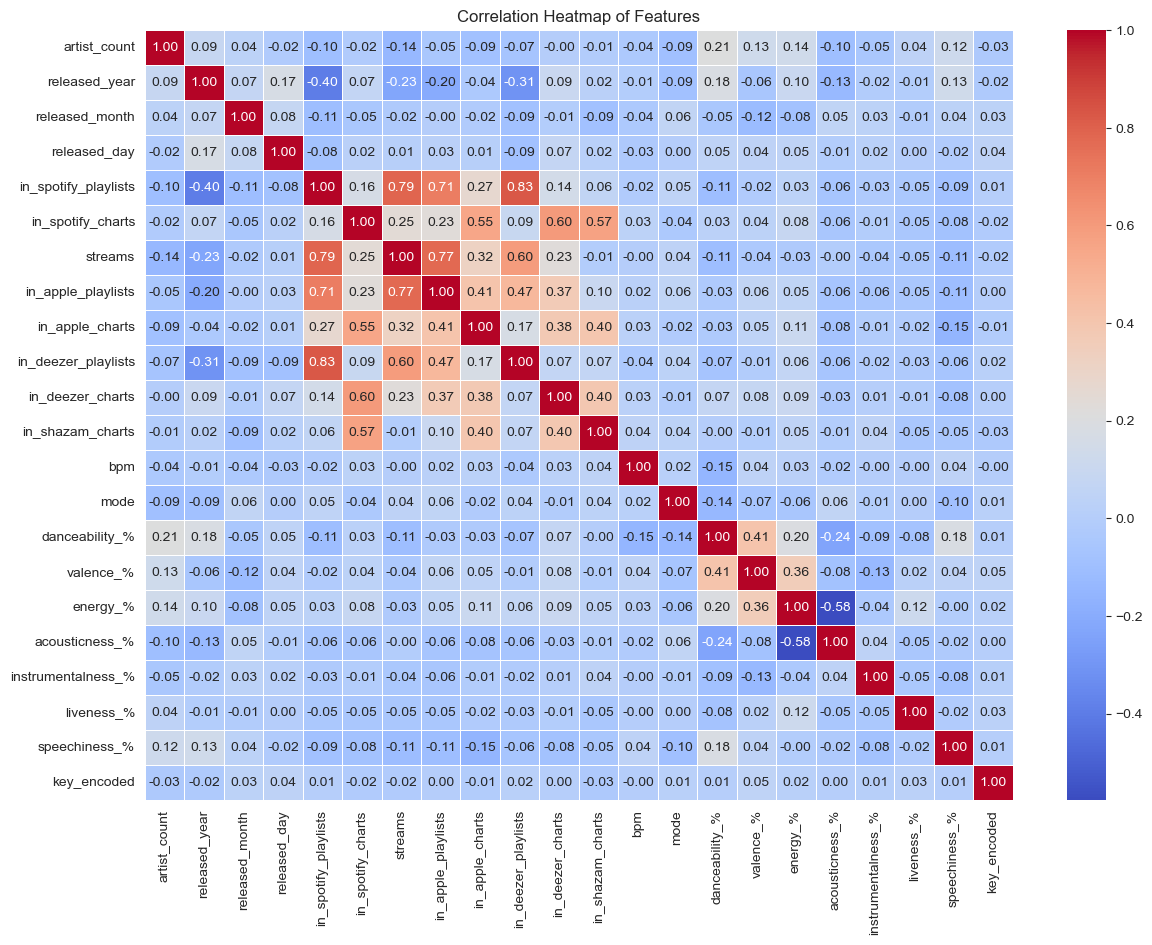

In [114]:
plt.figure(figsize = (14,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Features")
plt.show()

Explanation: Streams has a high correlation with in_spotify_playlist, in_spotify_charts and a decent relation with other platforms like Apple and Deezer. Features like instrumentalness_% and acousticness_% are negatively releated to the popularity.

#### Are some audio features highly related to popularity?

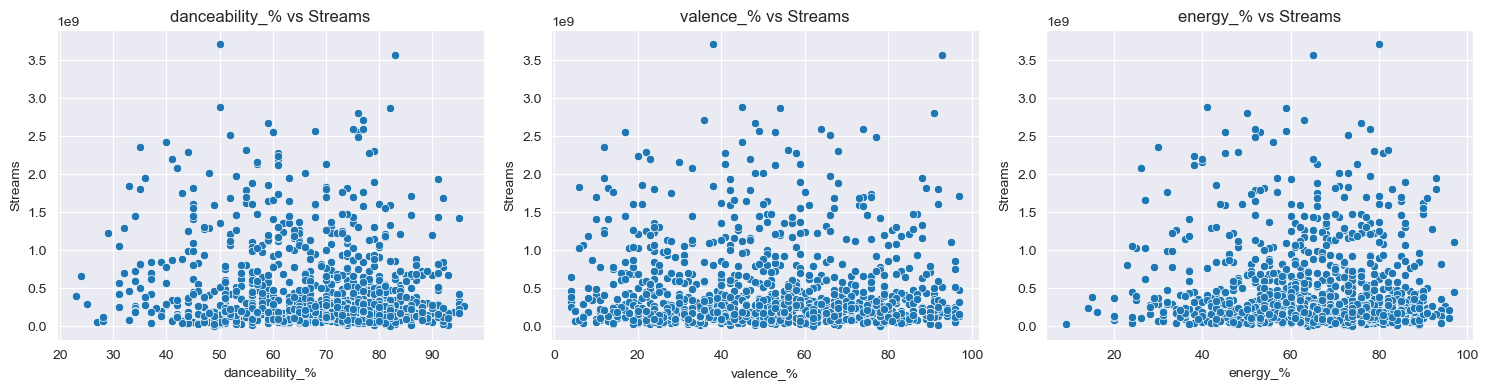

In [115]:
features_to_plot = ['danceability_%', 'valence_%', 'energy_%']
plt.figure(figsize = (15,4))
for i, feature in enumerate(features_to_plot):
    plt.subplot(1,3,i+1)
    sns.scatterplot(data=df, x=feature, y='streams')
    plt.title(f"{feature} vs Streams")
    plt.xlabel(feature)
    plt.ylabel("Streams")
plt.tight_layout()
plt.show()

Explanation: There doesn't seem to be a very strong trend, but the most high streaming songs fall in the mid-to-high range of these features. This suggests that while these features alone may not strongly predict popularity, they could still contribute when combined with other factors.

#### Do certain keys, modes, bpm or months lead to more popular songs?

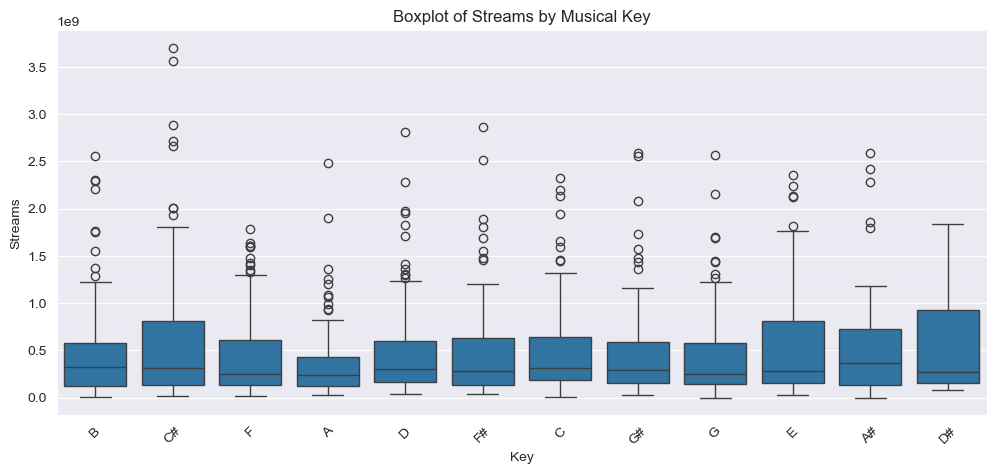

In [117]:
plt.figure(figsize = (12,5))
sns.boxplot(data=df, x='key', y='streams')
plt.title("Boxplot of Streams by Musical Key")
plt.xlabel("Key")
plt.ylabel("Streams")
plt.xticks(rotation=45)
plt.show()

Explanation: The overall number of streams doesn't change too much based on the key. The keys C# and E seem to have songs that got a lot more streams than usual.

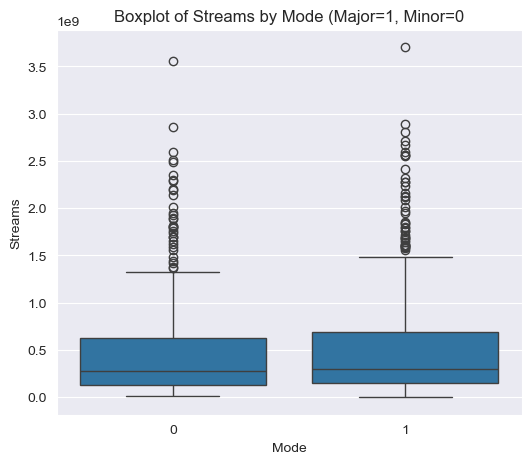

In [118]:
plt.figure(figsize = (6,5))
sns.boxplot(data=df, x='mode', y='streams')
plt.title("Boxplot of Streams by Mode (Major=1, Minor=0")
plt.xlabel("Mode")
plt.ylabel("Streams")
plt.show()

Explanation: Both types have similar results, but major(1) seems to have a few more songs with very high streams.

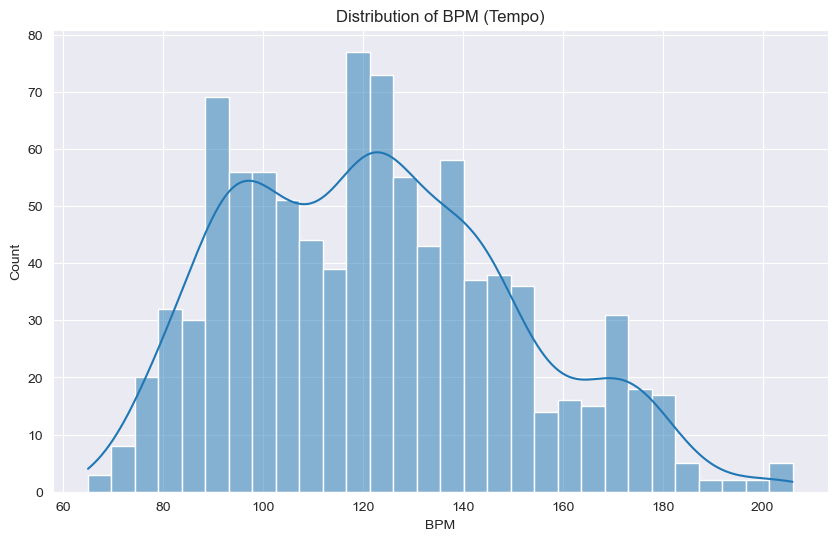

In [119]:
plt.figure(figsize = (10,6))
sns.histplot(df['bpm'], bins=30, kde=True)
plt.title("Distribution of BPM (Tempo)")
plt.xlabel("BPM")
plt.grid(True)
plt.show()

Explanation: The most popular songs are in a medium range tempo, around 120 BPM, which indicates that popular songs have a tempo that is not too slow and not too fast.

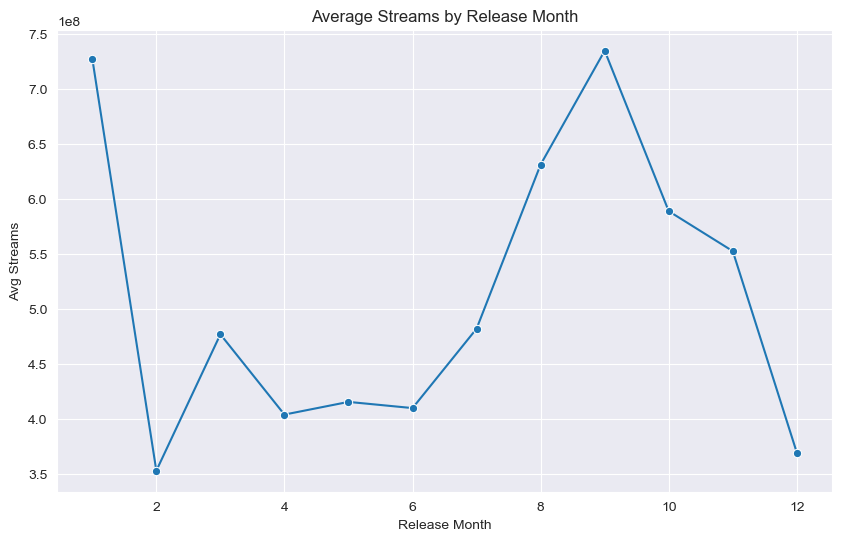

In [123]:
monthly_avg = df.groupby('released_month')['streams'].mean().reset_index()

plt.figure(figsize = (10,6))
sns.lineplot(data=monthly_avg, x='released_month', y='streams', marker='o')
plt.title("Average Streams by Release Month")
plt.xlabel("Release Month")
plt.ylabel("Avg Streams")
plt.grid(True)
plt.show()

Explanation: Songs released in January and September had the highest average streams nad there is a noticeable fall in February and December. This could be due to seasonal trends, festivals or industry release cycles. A factor to consider are also big artists releasing music during certain months. So while this pattern is useful it should not be over interpreted without deeper data.

#### Do platform variables actually influence popularity?

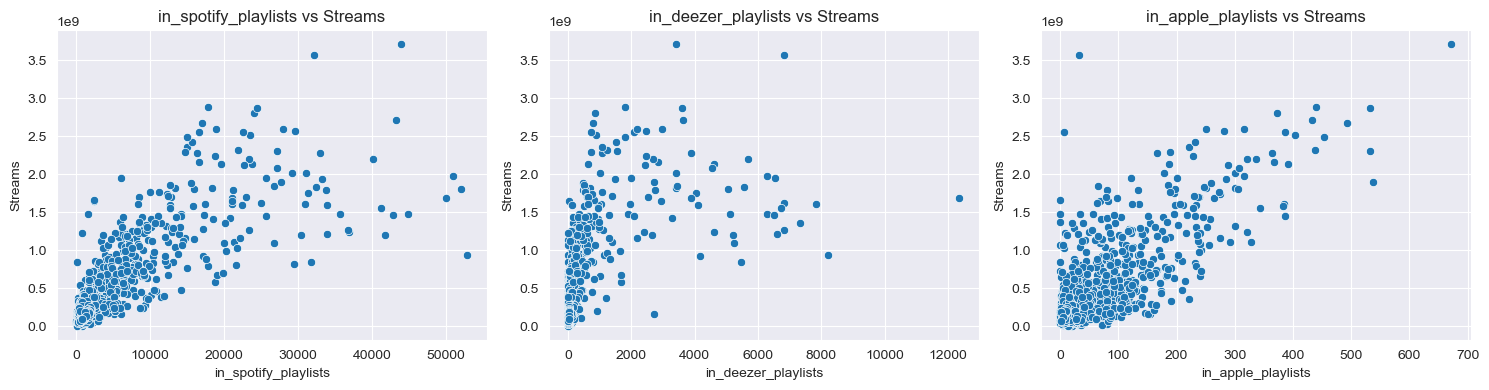

In [124]:
platform_features = ['in_spotify_playlists', 'in_deezer_playlists', 'in_apple_playlists']
plt.figure(figsize = (15,4))
for i, feature in enumerate(platform_features):
    plt.subplot(1,3,i+1)
    sns.scatterplot(data=df, x=feature, y='streams')
    plt.title(f"{feature} vs Streams")
    plt.xlabel(feature)
    plt.ylabel("Streams")
plt.tight_layout()
plt.show()

- Spotify: There is a strong trend that songs in more Spotify playlists get more streams
- Deezer: Fewer songs seem to have a large Deezer presence
- Apple Music: More playlist presence seems to lead to more streams, similar to Spotify.

Explanation: Songs that appear more in playlists tend to be streamed more, especially on Spotify and Apple Music.

## Train - Test Split

#### Before building the model, the data needs to be split into training and testing sets. The training set is used to learn patterns and the testing set to check how well it performs on unseen data.

Before splitting the data: the remaining object type column 'key', that was used for the EDA, can now be dropped, since the dataset has the encoded key feature.

In [125]:
model_train_df = df.drop(columns=['key'])

In [126]:
x = model_train_df.drop('streams', axis=1)
y = model_train_df['streams']

In [127]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

## Model Selection & Model Training

#### Key questions before selecting the model:
####
#### Q1. What is the goal?
#### - The goal is to predict the popularity of a song by number of streams using audio features and platform-related statistics.
#### - This is clearly a regression problem, because the output 'streams' is a continuos number and not a classification (like yes or no).
####
#### Q2. What is known about the data?
#### - The dataset can be considered small to medium, it has around 950 rows
#### - The data is cleaned and pre-processed
#### - The dataset has a mix of numeric features and a few encoded categorical features
#### - It is unclear if the has a linear relationship or something more complex
####
#### Q3. Which outcome should the model deliver?
#### - Understanding what influences popularity - something interpretable
#### - Getting good predictions
####
#### The plan:
#### Includes 3 models
#### - Linear Regression: It is simple and gives a good baseline to help understand the relationship of the data and feature impact
#### - Random Forest: Is used to find non-linear patterns and feature importance
#### - XGBoost: Can be used to optimize and push performance

In [130]:
def train_and_evaluate(model, x_train, x_test, y_train, y_test):
    model.fit(x_train, y_train)
    predictions = model.predict(x_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    print(f"Model: {model.__class__.__name__}")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"R2: {r2:.2f}")
    print("-" * 30)

    return {
        "Model": model.__class__.__name__,
        "MAE": mae,
        "MSE": mse,
        "R2": r2,
        "Model_object": model,
        "Predictions": predictions
    }

In [131]:
models_before_transform = [
    LinearRegression(),
    RandomForestRegressor(random_state=42)
]

results = []

for model in models_before_transform:
    result = train_and_evaluate(model, x_train, x_test, y_train, y_test)
    results.append(result)

Model: LinearRegression
MAE: 186665575.46
MSE: 70164083509558976.00
R2: 0.71
------------------------------
Model: RandomForestRegressor
MAE: 133711848.62
MSE: 43282841307622696.00
R2: 0.82
------------------------------


In [134]:
def evaluate_model_cv(model, x, y, cv=5):
    scores = cross_validate(model, x, y, cv=cv,
                            scoring=('r2', 'neg_mean_absolute_error', 'neg_mean_squared_error'),
                            return_train_score=False)

    print(f"Model: {model.__class__.__name__}")
    print(f"Mean R2: {scores['test_r2'].mean():.2f}")
    print(f"Mean MAE: {-scores['test_neg_mean_absolute_error'].mean():.2f}")
    print(f"Mean MSE: {-scores['test_neg_mean_squared_error'].mean():.2f}")
    print("-" * 30)

In [135]:
lin_reg = LinearRegression()
rf_reg = RandomForestRegressor(random_state=42)

evaluate_model_cv(lin_reg, x, y)
evaluate_model_cv(rf_reg, x, y)

Model: LinearRegression
Mean R2: 0.58
Mean MAE: 211822873.16
Mean MSE: 103002216302624688.00
------------------------------
Model: RandomForestRegressor
Mean R2: 0.71
Mean MAE: 167541351.68
Mean MSE: 69794061190678208.00
------------------------------


In [141]:
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

In [153]:
xgb_results = train_and_evaluate(xgb_model, x_train, x_test, y_train, y_test)

Model: XGBRegressor
MAE: 136584608.00
MSE: 44398928069656576.00
R2: 0.82
------------------------------


In [154]:
evaluate_model_cv(xgb_model, x_train, y_train)

Model: XGBRegressor
Mean R2: 0.80
Mean MAE: 150190956.80
Mean MSE: 64537216253794712.00
------------------------------


Log information of the streams column

In [155]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

Explanation: The streams column has a skewed distribution (some songs have millions of streams and other just a few thousand) which can affect the model performance and give more weight to very high values during training, making the model biased. Applying log transformation the range can get compressed and make the distribution more balanced.

In [156]:
y_train_log.head()

318    18.866742
545    20.212057
557    18.505105
109    20.874802
77     20.930829
Name: streams, dtype: float64

In [161]:
models_after_transform = [
    LinearRegression(),
    RandomForestRegressor(random_state=42),
    XGBRegressor(random_state=42, verbosity=0)
]

log_model_results = []
for model in models_after_transform:
    result = train_and_evaluate(model, x_train, x_test, y_train_log, y_test_log)
    log_model_results.append(result)

Model: LinearRegression
MAE: 0.55
MSE: 0.49
R2: 0.52
------------------------------
Model: RandomForestRegressor
MAE: 0.36
MSE: 0.22
R2: 0.79
------------------------------
Model: XGBRegressor
MAE: 0.37
MSE: 0.23
R2: 0.78
------------------------------


In [162]:
for model in models_after_transform:
    evaluate_model_cv(model, x_train, y_train_log)

Model: LinearRegression
Mean R2: 0.46
Mean MAE: 0.61
Mean MSE: 0.77
------------------------------
Model: RandomForestRegressor
Mean R2: 0.73
Mean MAE: 0.36
Mean MSE: 0.42
------------------------------
Model: XGBRegressor
Mean R2: 0.67
Mean MAE: 0.37
Mean MSE: 0.48
------------------------------


#### Differences in performance before and after Log Transformation
####
#### Without Log Transformation:
####  - The error metrics (MAE/MSE) were very large in absolute numbers
####  - Random Forest and XGBoost still performed well, but the results were in a different scale
####
#### With Log Transformation:
####  - Predictions are in log scale
####  - Error metrics like MAE, MSE and R2 are easier to interpret
####  - The performance of models became more consistent and reliable (especially visible in cross-validation)
####
#### What to use?
#### The Log Transformed model because:
####  - It's mathematically stable (less skewed)
####  - Helps avoid overfitting to songs with extreme stream values


## Feature Importance Analysis




#### Important things to understand in this part are:
#### - Which features are influencing the predictions the most?
#### - What information is important for other teams (like Marketing for example) about what makes a song likely to go viral?
#### This helps to turn the model into something actionable
#####
#### Concrete actions for this step:
#### a. Identify top features using RandomF orest Regressor and XGB Regressor
#### b. Visualize the feature importance
#### c. Interpret the results in simple terms
#### d. Suggest practical uses

In [163]:
def plot_feature_importance(model, x_train, top_n=10):
    importances = model.feature_importances_
    feature_names = x_train.columns
    feat_imp_def = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False).head(top_n)

    plt.figure(figsize = (10,6))
    sns.barplot( x='Importance', y='Feature', data=feat_imp_def, palette='viridis')
    plt.title(f"Top {top_n} Feature Importances - {model.__class__.__name__}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

C:\Users\Derum\AppData\Local\Temp\ipykernel_25076\1918969933.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( x='Importance', y='Feature', data=feat_imp_def, palette='viridis')


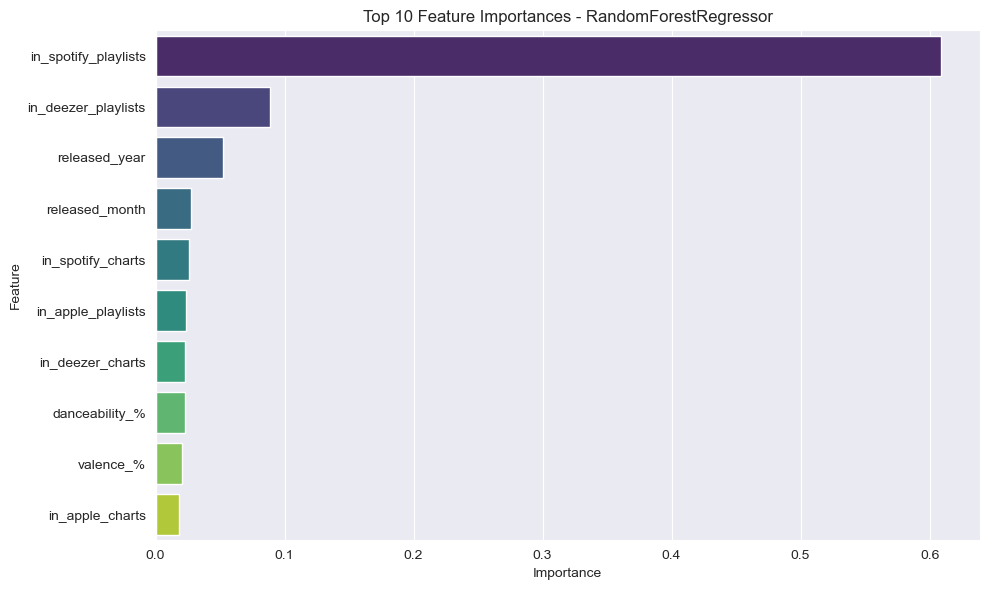

In [164]:
plot_feature_importance(models_after_transform[1], x_train)

The most dominant feature is:
- in_spotify_playlist: By far the highest importance is how much a song is added to spotify playlists. So playlist exposure is a major driver for streams.

Other useful features:
- in_deezer_playlists, released_year and in_spotify_charts are also important, but much less compared to in_spotify_playlists

C:\Users\Derum\AppData\Local\Temp\ipykernel_25076\1918969933.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( x='Importance', y='Feature', data=feat_imp_def, palette='viridis')


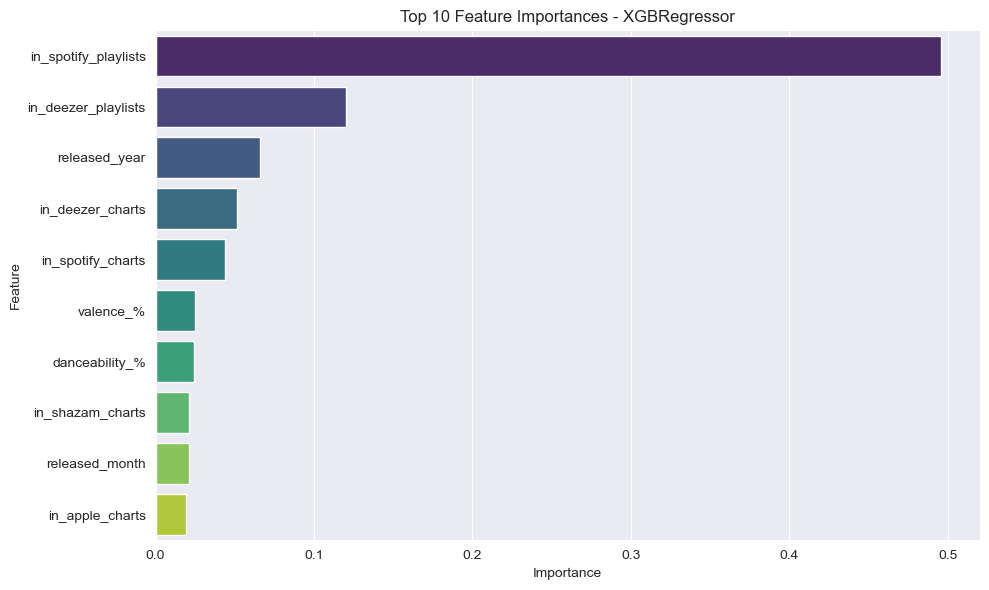

In [165]:
plot_feature_importance(models_after_transform[2], x_train)

The most important feature is again in_spotify_playlists, followed by in_deezer_playlists, released_year and platform charts presence

#### From both models, it can be concluded:
#### - Platform presence, especially on Spotify, is the strongest predictor of a song's success
#### - Audio features are helpful but secondary

## The End

#### The data analysis is completed and there are multiple models to predict song popularity
####
#### The next step is to shift the modular code structure. This means:
#### - Keeping the training logic, evaluation and utilities in separate clean files
#### - Making the code more reusable, readable and easier to debug or upgrade later
####
#### After this, the final model gets deployed using Streamlit, so a clean front end
#### can be build where users can input song features and see the predicted popularity.
#### Key insights from the EDA and model training phase will be included to help internal teams make data driven decisions.